# S&P 500 Stock Dataset

## Nạp và lọc dữ liệu cổ phiếu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Nạp dữ liệu
df = pd.read_csv("DATA/Stock_Market_Data/all_stocks_5yr.csv")

# 2. Lọc dữ liệu cho 1 mã cổ phiếu (Ví dụ: Apple - AAPL)
# Mạng RNN cần chuỗi thời gian liền mạch của 1 chủ thể, không trộn lẫn các công ty
df_stock = df[df['Name'] == 'AAPL'].copy()

# 3. Định dạng lại cột thời gian và sắp xếp
df_stock['date'] = pd.to_datetime(df_stock['date'])
df_stock = df_stock.sort_values('date')

print(f"Kích thước dữ liệu gốc (Tất cả cổ phiếu): {df.shape}")
print(f"Kích thước dữ liệu đã lọc (Mã AAPL): {df_stock.shape}")
display(df_stock.head())

Kích thước dữ liệu gốc (Tất cả cổ phiếu): (619040, 7)
Kích thước dữ liệu đã lọc (Mã AAPL): (1259, 7)


,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


## Khám phá dữ liệu (EDA) - Trực quan hóa giá và khối lượng giao dịch

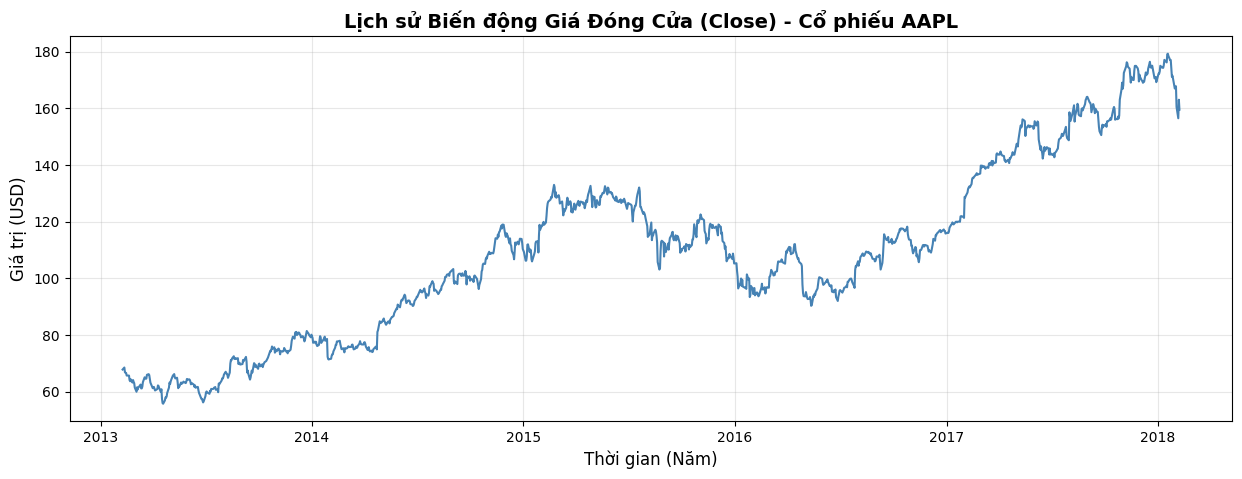

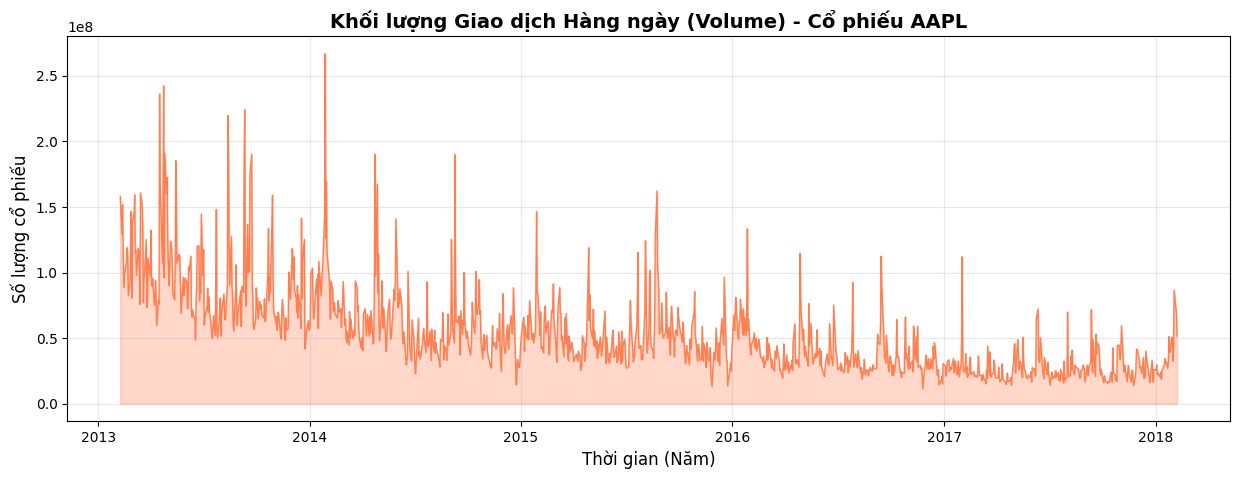

In [4]:
# BIỂU ĐỒ 1: GIÁ CỔ PHIẾU (CLOSE PRICE)
plt.figure(figsize=(15, 5))
plt.plot(df_stock['date'], df_stock['close'], color='steelblue', linewidth=1.5)
plt.title('Lịch sử Biến động Giá Đóng Cửa (Close) - Cổ phiếu AAPL', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Năm)', fontsize=12)
plt.ylabel('Giá trị (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# BIỂU ĐỒ 2: KHỐI LƯỢNG GIAO DỊCH (VOLUME)
plt.figure(figsize=(15, 5))
plt.plot(df_stock['date'], df_stock['volume'], color='coral', linewidth=1)
plt.fill_between(df_stock['date'], df_stock['volume'], color='coral', alpha=0.3)
plt.title('Khối lượng Giao dịch Hàng ngày (Volume) - Cổ phiếu AAPL', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Năm)', fontsize=12)
plt.ylabel('Số lượng cổ phiếu', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Chia Train/Test tuần tự và chuẩn hóa (Scaling)

In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. Trích xuất đặc trưng (Bài toán đơn biến: Chỉ dùng cột giá 'close')
data = df_stock[['close']].values

# 2. Phân chia Train/Test THEO TRÌNH TỰ THỜI GIAN
# Tuyệt đối không dùng train_test_split (ngẫu nhiên) để tránh việc dự báo quá khứ từ tương lai
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# 3. Chuẩn hóa dữ liệu (Scaling) về khoảng [0, 1] cho RNN
scaler = MinMaxScaler(feature_range=(0, 1))

# Lưu ý quan trọng: Chỉ học Min/Max (fit) trên tập Train
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

print("--- THỐNG KÊ SAU KHI CHIA TẬP ---")
print(f"Tổng số ngày: {len(data)}")
print(f"Tập Train (80%): {len(scaled_train)} ngày")
print(f"Tập Test (20%):  {len(scaled_test)} ngày")

--- THỐNG KÊ SAU KHI CHIA TẬP ---
Tổng số ngày: 1259
Tập Train (80%): 1007 ngày
Tập Test (20%):  252 ngày


## Tạo Tensor 3D với cơ chế Cửa sổ trượt (Sliding Window)

In [6]:
# Hàm tạo dữ liệu cửa sổ trượt (Sliding Window)
def create_dataset(dataset, time_steps):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        # Dữ liệu của time_steps ngày (Input)
        X.append(dataset[i : (i + time_steps), 0])
        # Dữ liệu ngày tiếp theo (Label)
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

# Cấu hình Số bước thời gian (Dùng 60 ngày quá khứ để dự báo tương lai)
TIME_STEPS = 60
NUM_FEATURES = 1 # Do chỉ dự báo bằng 1 cột 'close'

X_train, y_train = create_dataset(scaled_train, TIME_STEPS)
X_test, y_test = create_dataset(scaled_test, TIME_STEPS)

# Mạng RNN yêu cầu Input phải ở dạng 3D: (Samples, Time Steps, Features)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], NUM_FEATURES))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], NUM_FEATURES))

print("\n--- ĐỊNH DẠNG TENSOR 3D HOÀN CHỈNH CHO RNN/LSTM ---")
print(f"Định dạng yêu cầu: (Số lượng mẫu, Số bước thời gian, Số đặc trưng)")
print(f"X_train_rnn shape: {X_train_rnn.shape}")
print(f"y_train shape:     {y_train.shape}")
print(f"X_test_rnn shape:  {X_test_rnn.shape}")
print(f"y_test shape:      {y_test.shape}")


--- ĐỊNH DẠNG TENSOR 3D HOÀN CHỈNH CHO RNN/LSTM ---
Định dạng yêu cầu: (Số lượng mẫu, Số bước thời gian, Số đặc trưng)
X_train_rnn shape: (947, 60, 1)
y_train shape:     (947,)
X_test_rnn shape:  (192, 60, 1)
y_test shape:      (192,)


# Jena Climate Dataset

## Nạp, lấy mẫu theo giờ và lọc dữ liệu

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Nạp dữ liệu
df = pd.read_csv("DATA/Weather_Data/jena_climate_2009_2016.csv")

# 2. Rút gọn dữ liệu (Downsampling)
# Dữ liệu gốc ghi nhận 10 phút/lần. Ta trích xuất mỗi dòng thứ 6 để có dữ liệu hàng giờ.
df = df[5::6].copy()

# 3. Lấy cột Thời gian, Nhiệt độ và ĐỘ ẨM (rh (%))
df_weather = df[['Date Time', 'T (degC)', 'rh (%)']].copy()

# Định dạng cột thời gian và sắp xếp
df_weather['Date Time'] = pd.to_datetime(df_weather['Date Time'], format='%d.%m.%Y %H:%M:%S')
df_weather = df_weather.sort_values('Date Time')

print(f"Kích thước dữ liệu gốc: {df.shape}")
print(f"Kích thước sau khi chuyển về tần suất Giờ: {df_weather.shape}")
display(df_weather.head())

Kích thước dữ liệu gốc: (70091, 15)
Kích thước sau khi chuyển về tần suất Giờ: (70091, 3)


,Date Time,T (degC),rh (%)
5,2009-01-01 01:00:00,-8.05,94.4
11,2009-01-01 02:00:00,-8.88,93.2
17,2009-01-01 03:00:00,-8.81,93.5
23,2009-01-01 04:00:00,-9.05,92.6
29,2009-01-01 05:00:00,-9.63,92.2


## Khám phá dữ liệu (EDA) và trực quan hóa

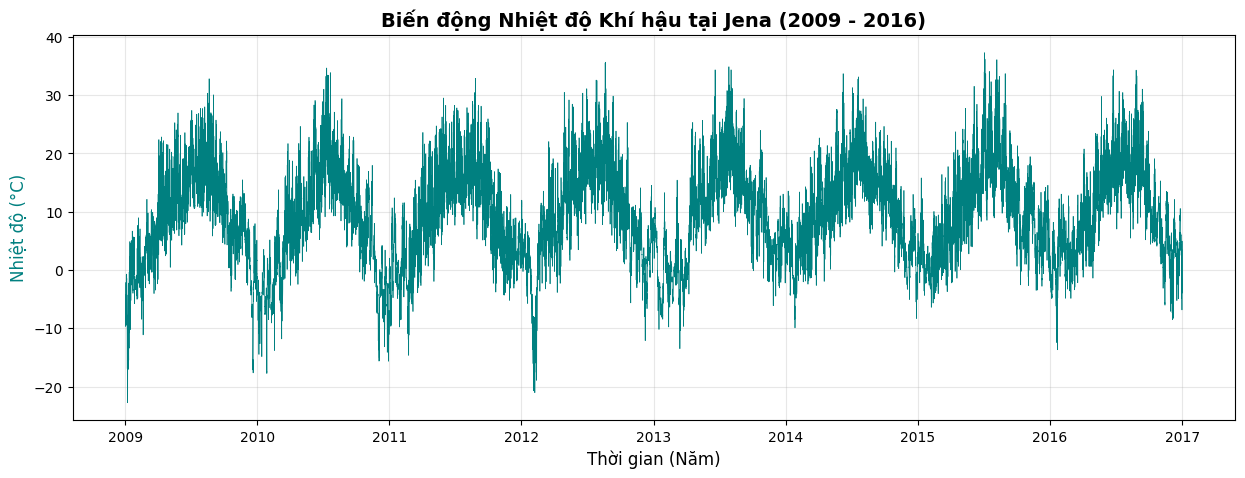

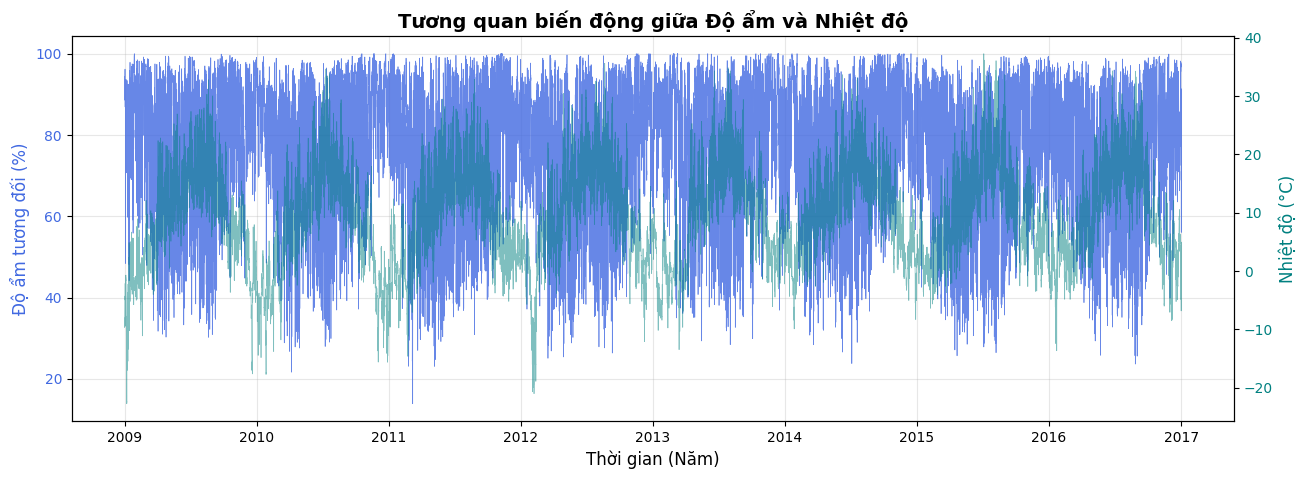

In [9]:
# BIỂU ĐỒ 1: NHIỆT ĐỘ THEO THỜI GIAN
plt.figure(figsize=(15, 5))
plt.plot(df_weather['Date Time'], df_weather['T (degC)'], color='teal', linewidth=0.5)
plt.title('Biến động Nhiệt độ Khí hậu tại Jena (2009 - 2016)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Năm)', fontsize=12)
plt.ylabel('Nhiệt độ (°C)', fontsize=12, color='teal')
plt.grid(True, alpha=0.3)
plt.show()

# BIỂU ĐỒ 2: ĐỘ ẨM VÀ NHIỆT ĐỘ THEO THỜI GIAN
fig, ax1 = plt.subplots(figsize=(15, 5))

# Vẽ Độ ẩm (trục Y bên trái)
ax1.plot(df_weather['Date Time'], df_weather['rh (%)'], color='royalblue', linewidth=0.5, alpha=0.8)
ax1.set_ylabel('Độ ẩm tương đối (%)', fontsize=12, color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xlabel('Thời gian (Năm)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Vẽ Nhiệt độ (trục Y bên phải) dùng chung trục X
ax2 = ax1.twinx() 
ax2.plot(df_weather['Date Time'], df_weather['T (degC)'], color='teal', linewidth=0.5, alpha=0.5)
ax2.set_ylabel('Nhiệt độ (°C)', fontsize=12, color='teal')
ax2.tick_params(axis='y', labelcolor='teal')

plt.title('Tương quan biến động giữa Độ ẩm và Nhiệt độ', fontsize=14, fontweight='bold')
plt.show()

## Trích xuất đa biến và chuẩn hóa

In [10]:
from sklearn.preprocessing import MinMaxScaler

# 1. Trích xuất ĐA BIẾN: Lấy cả Nhiệt độ (cột 0) và Độ ẩm (cột 1)
data = df_weather[['T (degC)', 'rh (%)']].values

# 2. Phân chia Train/Test THEO TRÌNH TỰ THỜI GIAN
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# 3. Chuẩn hóa dữ liệu cho CẢ 2 cột về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

print("--- THỐNG KÊ SAU KHI CHIA TẬP ---")
print(f"Tổng số giờ quan trắc: {len(data)}")
print(f"Tập Train (80%): {len(scaled_train)} giờ")
print(f"Tập Test (20%):  {len(scaled_test)} giờ")
print(f"Số lượng đặc trưng (Features): {data.shape[1]}")

--- THỐNG KÊ SAU KHI CHIA TẬP ---
Tổng số giờ quan trắc: 70091
Tập Train (80%): 56072 giờ
Tập Test (20%):  14019 giờ
Số lượng đặc trưng (Features): 2


## Tạo Tensor 3D cho dự báo đa biến

In [11]:
# Hàm tạo tập dữ liệu trượt cho đa biến
def create_dataset_multivariate(dataset, time_steps):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        # Lấy TẤT CẢ các đặc trưng (Nhiệt độ & Độ ẩm) của time_steps giờ qua
        X.append(dataset[i : (i + time_steps), :])
        
        # Chỉ lấy NHIỆT ĐỘ (cột index 0) của giờ tiếp theo làm nhãn dự đoán
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

# Cấu hình cửa sổ thời gian
TIME_STEPS = 24  
NUM_FEATURES = 2 # Đã tăng lên 2 do dùng cả Nhiệt độ và Độ ẩm

X_train, y_train = create_dataset_multivariate(scaled_train, TIME_STEPS)
X_test, y_test = create_dataset_multivariate(scaled_test, TIME_STEPS)

# Dữ liệu X đã ở sẵn định dạng 3D từ hàm bên trên, ta chỉ in ra kiểm tra
print("\n--- ĐỊNH DẠNG TENSOR 3D HOÀN CHỈNH CHO RNN/LSTM ---")
print(f"Cấu trúc chuẩn: (Số lượng mẫu, Số bước thời gian, Số đặc trưng)")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


--- ĐỊNH DẠNG TENSOR 3D HOÀN CHỈNH CHO RNN/LSTM ---
Cấu trúc chuẩn: (Số lượng mẫu, Số bước thời gian, Số đặc trưng)
X_train shape: (56048, 24, 2)
y_train shape: (56048,)
X_test shape:  (13995, 24, 2)
y_test shape:  (13995,)


# Store Item Demand Forecasting Challenge

## Nạp dữ liệu và gom nhóm theo ngày

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Nạp dữ liệu huấn luyện
df_train = pd.read_csv("DATA/Transaction_Data/train.csv")

# 2. Lọc chuỗi thời gian cho 1 tổ hợp Cửa hàng - Mặt hàng 
# (Ví dụ: Lấy dữ liệu bán hàng của Cửa hàng 1, Mặt hàng 1)
df_item = df_train[(df_train['store'] == 1) & (df_train['item'] == 1)].copy()

# 3. Định dạng thời gian và sắp xếp
df_item['date'] = pd.to_datetime(df_item['date'])
df_item = df_item.sort_values('date')

print(f"Kích thước dữ liệu gốc: {df_train.shape}")
print(f"Kích thước dữ liệu sau khi lọc (Store 1 - Item 1): {df_item.shape}")
display(df_item.head())

Kích thước dữ liệu gốc: (913000, 4)
Kích thước dữ liệu sau khi lọc (Store 1 - Item 1): (1826, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Khám phá dữ liệu (EDA) - Trực quan hóa số lượng và xu hướng

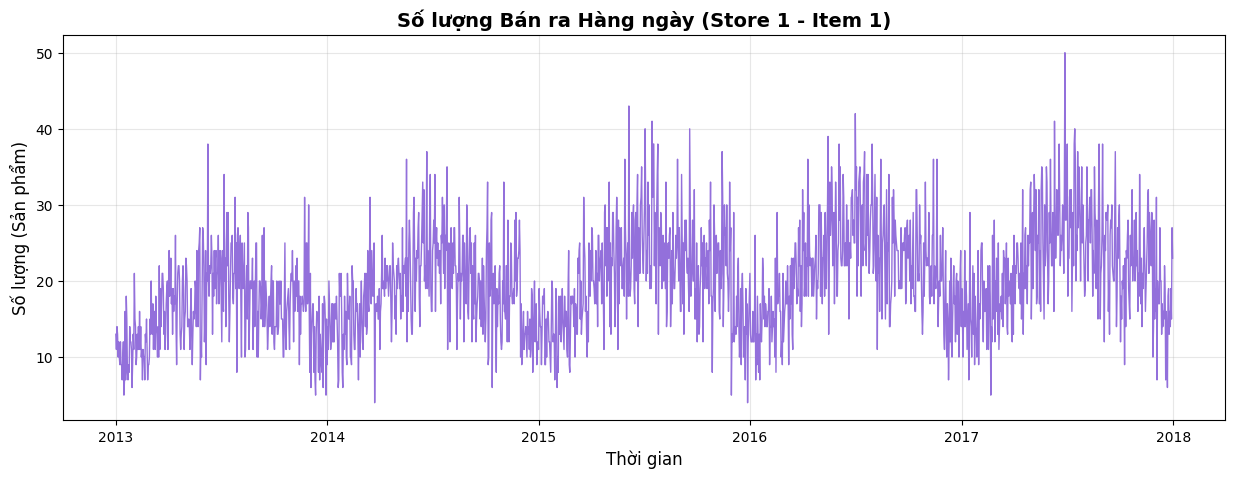

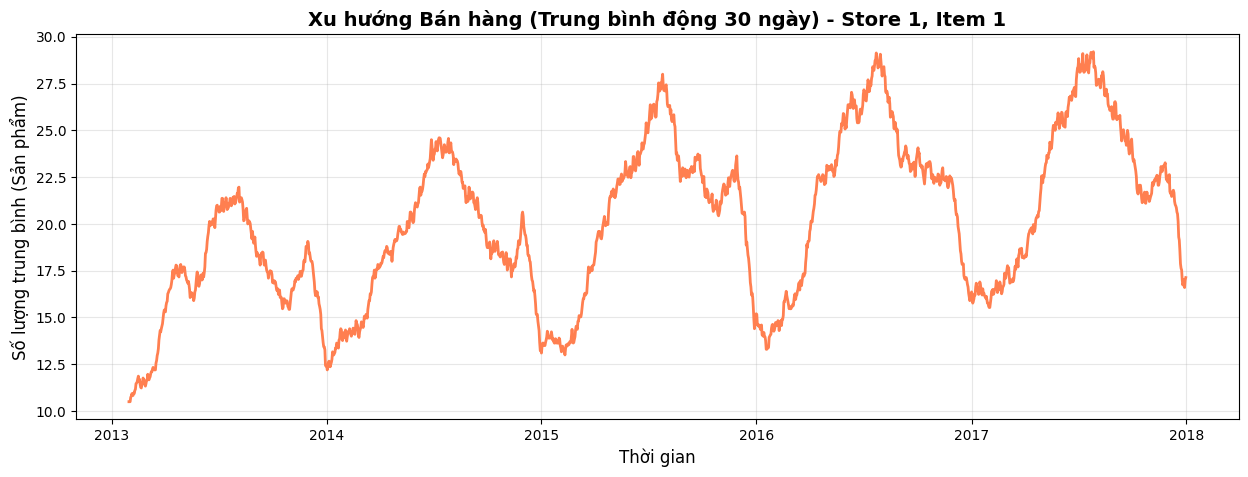

In [13]:
# BIỂU ĐỒ 1: SỐ LƯỢNG BÁN HÀNG NGÀY
plt.figure(figsize=(15, 5))
plt.plot(df_item['date'], df_item['sales'], color='mediumpurple', linewidth=1)
plt.title('Số lượng Bán ra Hàng ngày (Store 1 - Item 1)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lượng (Sản phẩm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# BIỂU ĐỒ 2: ĐƯỜNG XU HƯỚNG BÁN HÀNG (TRUNG BÌNH ĐỘNG 30 NGÀY)
# Tính trung bình động 30 ngày để loại bỏ nhiễu, nhìn rõ xu hướng mùa vụ
df_item['ma_30'] = df_item['sales'].rolling(window=30).mean()

plt.figure(figsize=(15, 5))
plt.plot(df_item['date'], df_item['ma_30'], color='coral', linewidth=2)
plt.title('Xu hướng Bán hàng (Trung bình động 30 ngày) - Store 1, Item 1', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lượng trung bình (Sản phẩm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Chia tập Validation cục bộ và chuẩn hóa

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Trích xuất cột Số lượng bán (sales)
data = df_item[['sales']].values

# CHIA TẬP TUẦN TỰ THỜI GIAN (80% Train, 20% Validation)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
val_data = data[train_size:]

# Chuẩn hóa về [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Chỉ fit trên tập Train
scaled_train = scaler.fit_transform(train_data)
scaled_val = scaler.transform(val_data)

print("--- THỐNG KÊ CHIA TẬP ---")
print(f"Tổng số ngày: {len(data)}")
print(f"Tập Train: {len(scaled_train)} ngày")
print(f"Tập Validation: {len(scaled_val)} ngày")

--- THỐNG KÊ CHIA TẬP ---
Tổng số ngày: 1826
Tập Train: 1460 ngày
Tập Validation: 366 ngày


## Tạo Tensor 3D (Cửa sổ trượt)
Dùng lịch sử bán hàng của 30 ngày trước để dự đoán số lượng bán ra vào ngày tiếp theo.

In [31]:
# ==============================================================================
# CELL 1: ĐỒNG BỘ DỮ LIỆU ĐẦU VÀO CHO MẠNG RNN TỪ TẬP AAPL
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Trích xuất cột giá đóng cửa của AAPL
data = df_stock[['close']].values

# 2. Chia Train/Test tuần tự theo thời gian (80% Train, 20% Test)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# 3. Chuẩn hóa dữ liệu về đoạn [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

# 4. Tạo Sliding Window (60 ngày quá khứ để dự báo 1 ngày tiếp theo)
def create_dataset(dataset, time_steps=60):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i : (i + time_steps), 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60
NUM_FEATURES = 1

X_train, y_train = create_dataset(scaled_train, TIME_STEPS)
X_test, y_test = create_dataset(scaled_test, TIME_STEPS)

# 5. Định dạng lại thành Tensor 3D cho mạng RNN: (Samples, Time Steps, Features)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], NUM_FEATURES))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], NUM_FEATURES))

print("--- THỐNG KÊ ĐỒNG BỘ DỮ LIỆU ---")
print(f"X_train_rnn shape: {X_train_rnn.shape} | y_train shape: {y_train.shape}")
print(f"X_test_rnn shape:  {X_test_rnn.shape}  | y_test shape:  {y_test.shape}")

--- THỐNG KÊ ĐỒNG BỘ DỮ LIỆU ---
X_train_rnn shape: (947, 60, 1) | y_train shape: (947,)
X_test_rnn shape:  (192, 60, 1)  | y_test shape:  (192,)


In [32]:
# ==============================================================================
# CELL 2: XÂY DỰNG KIẾN TRÚC MÔ HÌNH RNN (STACKED SIMPLERNN)
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout

# Thiết lập seed để cố định kết quả tái lập
tf.random.set_seed(42)
np.random.seed(42)

# Khởi tạo mô hình mạng RNN xếp chồng (Stacked RNN gồm 4 lớp học tham số)
model_rnn = Sequential([
    # Lớp Input định hình khung dữ liệu đầu vào (60 time-steps, 1 feature)
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    
    # Lớp SimpleRNN thứ nhất: Trả về toàn bộ chuỗi (return_sequences=True)
    SimpleRNN(units=64, activation='tanh', return_sequences=True),
    Dropout(0.2), # Giảm thiểu overfitting
    
    # Lớp SimpleRNN thứ hai: Chỉ trả về trạng thái ẩn ở time-step cuối cùng
    SimpleRNN(units=32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    
    # Lớp Dense ẩn kết nối đầy đủ tinh chỉnh đặc trưng
    Dense(units=16, activation='relu'),
    
    # Lớp Output: 1 node tuyến tính dự báo giá trị liên tục (Regression)
    Dense(units=1)
])

# Hiển thị cấu trúc chi tiết mô hình
model_rnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)             │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_7 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# ==============================================================================
# CELL 3: CẤU HÌNH LOSS, BỘ TỐI ƯU VÀ THUẬT TOÁN BPTT
# ==============================================================================
# 1. Thuật toán tối ưu hóa Adam điều chỉnh tốc độ học tự động
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# 2. Hàm mất mát: Mean Squared Error (MSE) - chuẩn cho bài toán hồi quy
# Chỉ số theo dõi: MAE (Mean Absolute Error)
model_rnn.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("Đã thiết lập cấu hình biên dịch thành công (Optimizer: Adam, Loss: MSE, Thuật toán: BPTT).")


Đã thiết lập cấu hình biên dịch thành công (Optimizer: Adam, Loss: MSE, Thuật toán: BPTT).


In [34]:
# ==============================================================================
# CELL 4: VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# ==============================================================================
from tensorflow.keras.callbacks import EarlyStopping

# Cơ chế Early Stopping tự động dừng nếu sau 10 epochs val_loss không giảm
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True, 
    verbose=1
)

EPOCHS = 50
BATCH_SIZE = 32

history = model_rnn.fit(
    X_train_rnn, 
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_rnn, y_test),
    callbacks=[early_stop],
    shuffle=False,  # Tuyệt đối không xáo trộn để đảm bảo tính liên tục của chuỗi thời gian
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0784 - mean_absolute_error: 0.2280 - val_loss: 0.4886 - val_mean_absolute_error: 0.6801
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0996 - mean_absolute_error: 0.2518 - val_loss: 0.3955 - val_mean_absolute_error: 0.6211
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0329 - mean_absolute_error: 0.1398 - val_loss: 0.2468 - val_mean_absolute_error: 0.4905
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0255 - mean_absolute_error: 0.1262 - val_loss: 0.3225 - val_mean_absolute_error: 0.5595
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0191 - mean_absolute_error: 0.1065 - val_loss: 0.2354 - val_mean_absolute_error: 0.4779
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0145 - mean_absolute_error: 0.0918 - val_loss: 0.2421 - val_mean_absolute_error: 0.4845
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0142 - mean_absolute_error: 0.0927 - val_loss

In [35]:
# ==============================================================================
# CELL 5: DỰ BÁO TRÊN TẬP TEST VÀ ĐÁNH GIÁ CÁC CHỈ SỐ SAI SỐ
# ==============================================================================
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Dự báo trên tập Test
y_pred_scaled = model_rnn.predict(X_test_rnn)

# 2. Nghịch đảo chuẩn hóa (Inverse Transform) về giá trị tiền tệ USD thực tế
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred_scaled)

# 3. Tính toán các chỉ số đánh giá mô hình
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("=" * 60)
print("     KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RNN TRÊN TẬP KIỂM THỬ (TEST)")
print("=" * 60)
print(f"Mean Squared Error (MSE):         {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):   {rmse:.4f} USD")
print(f"Mean Absolute Error (MAE):        {mae:.4f} USD")
print(f"Hệ số xác định R-squared (R²):     {r2:.4f}")
print("=" * 60)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
     KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RNN TRÊN TẬP KIỂM THỬ (TEST)
Mean Squared Error (MSE):         445.3837
Root Mean Squared Error (RMSE):   21.1041 USD
Mean Absolute Error (MAE):        20.5024 USD
Hệ số xác định R-squared (R²):     -3.4623


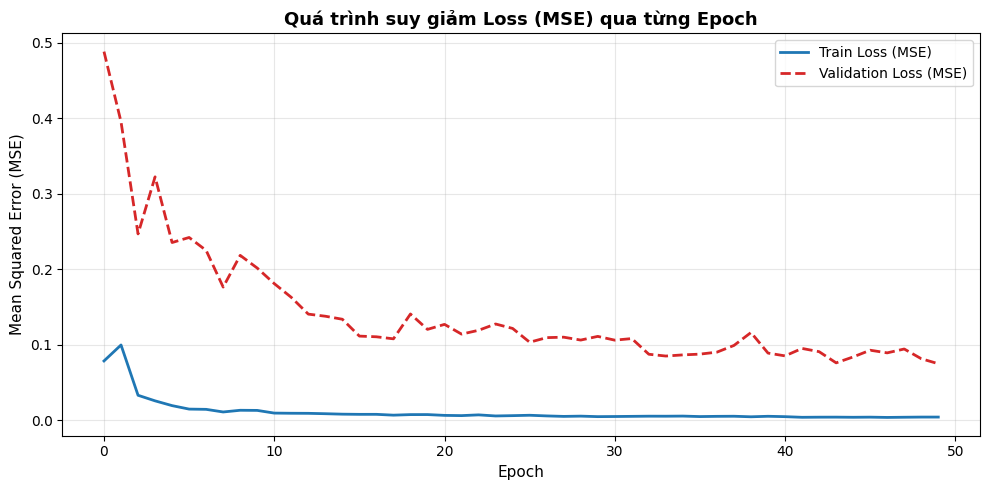

In [36]:
# ==============================================================================
# BIỂU ĐỒ 1: QUÁ TRÌNH HỘI TỤ LOSS (MSE) QUA CÁC EPOCH
# ==============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#d62728', linestyle='--', linewidth=2)

plt.title('Quá trình suy giảm Loss (MSE) qua từng Epoch', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

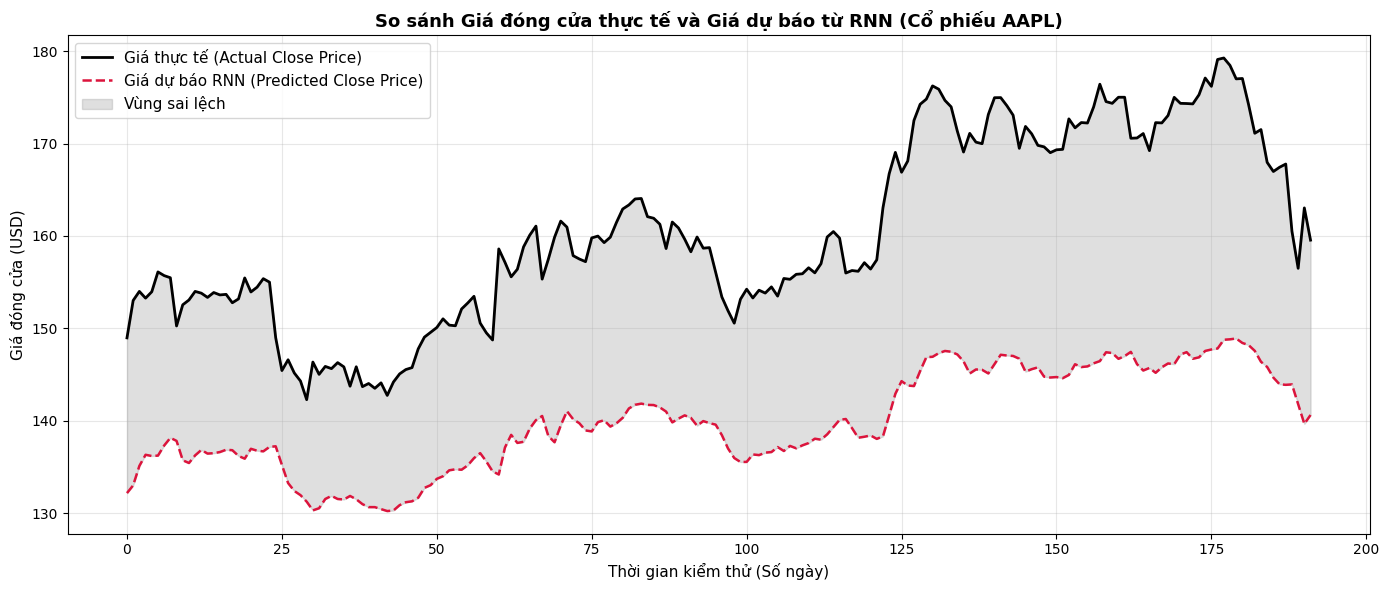

In [37]:
# ==============================================================================
# BIỂU ĐỒ 2: ĐƯỜNG GIÁ THỰC TẾ VS GIÁ DỰ BÁO CỦA MÔ HÌNH RNN
# ==============================================================================
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, color='black', linewidth=2, label='Giá thực tế (Actual Close Price)')
plt.plot(y_pred_real, color='crimson', linewidth=1.8, linestyle='--', label='Giá dự báo RNN (Predicted Close Price)')

# Vùng bóng xám thể hiện độ lệch sai số
plt.fill_between(range(len(y_test_real)), y_test_real.flatten(), y_pred_real.flatten(), color='gray', alpha=0.25, label='Vùng sai lệch')

plt.title('So sánh Giá đóng cửa thực tế và Giá dự báo từ RNN (Cổ phiếu AAPL)', fontsize=13, fontweight='bold')
plt.xlabel('Thời gian kiểm thử (Số ngày)', fontsize=11)
plt.ylabel('Giá đóng cửa (USD)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

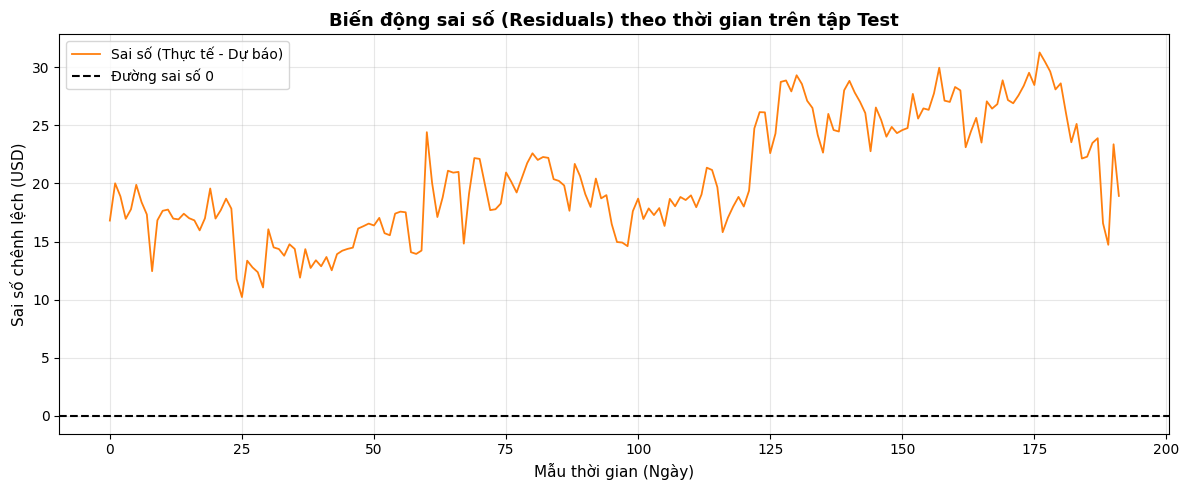

In [38]:
# ==============================================================================
# BIỂU ĐỒ 3: BIẾN ĐỘNG SAI SỐ (RESIDUALS) THEO THỜI GIAN
# ==============================================================================
residuals = y_test_real - y_pred_real

plt.figure(figsize=(12, 5))
plt.plot(residuals, color='#ff7f0e', linewidth=1.3, label='Sai số (Thực tế - Dự báo)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, label='Đường sai số 0')

plt.title('Biến động sai số (Residuals) theo thời gian trên tập Test', fontsize=13, fontweight='bold')
plt.xlabel('Mẫu thời gian (Ngày)', fontsize=11)
plt.ylabel('Sai số chênh lệch (USD)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

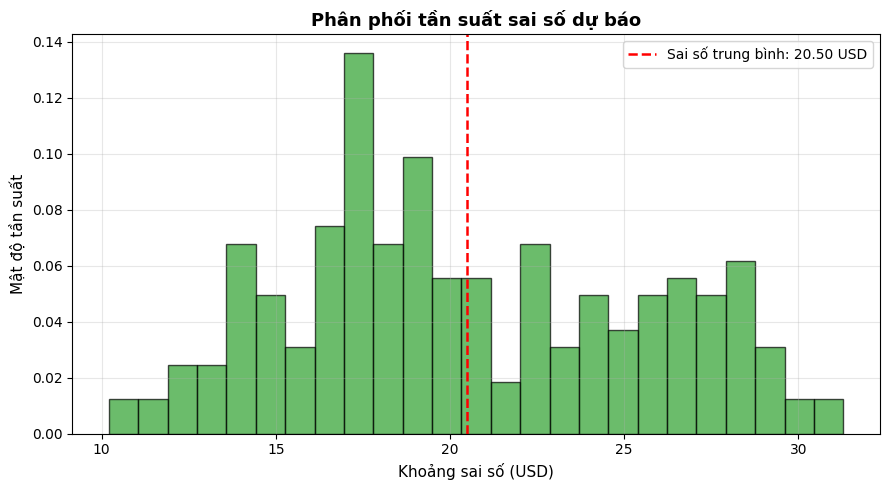

In [39]:
# ==============================================================================
# BIỂU ĐỒ 4: PHÂN PHỐI TẦN SUẤT SAI SỐ (ERROR DISTRIBUTION)
# ==============================================================================
import numpy as np

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=25, color='#2ca02c', edgecolor='black', alpha=0.7, density=True)
plt.axvline(x=np.mean(residuals), color='red', linestyle='--', linewidth=1.8, label=f'Sai số trung bình: {np.mean(residuals):.2f} USD')

plt.title('Phân phối tần suất sai số dự báo', fontsize=13, fontweight='bold')
plt.xlabel('Khoảng sai số (USD)', fontsize=11)
plt.ylabel('Mật độ tần suất', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

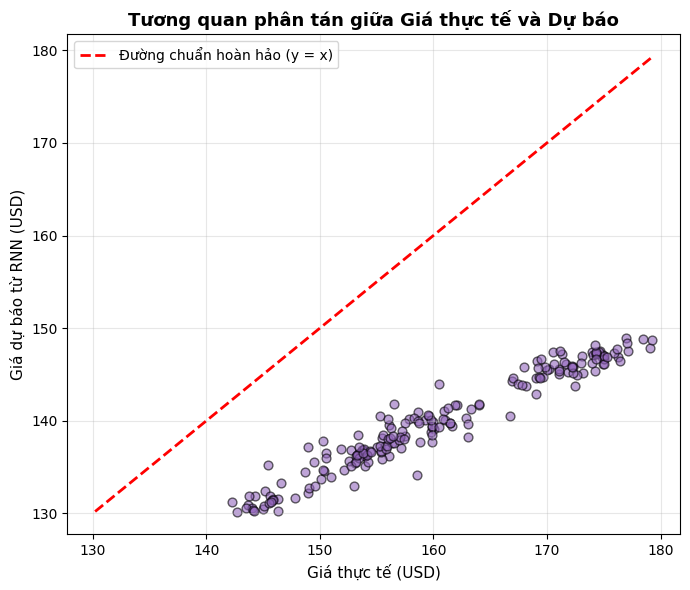

In [40]:
# ==============================================================================
# BIỂU ĐỒ 5: TƯƠNG QUAN PHÂN TÁN (SCATTER PLOT & ĐƯỜNG CHUẨN 45 ĐỘ)
# ==============================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.6, color='#9467bd', edgecolors='k', s=40)

# Vẽ đường chéo y = x
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường chuẩn hoàn hảo (y = x)')

plt.title('Tương quan phân tán giữa Giá thực tế và Dự báo', fontsize=13, fontweight='bold')
plt.xlabel('Giá thực tế (USD)', fontsize=11)
plt.ylabel('Giá dự báo từ RNN (USD)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# ==============================================================================
# LƯU MÔ HÌNH VÀ SCALER RA THƯ MỤC MODELS (DEPLOYMENT READY)
# ==============================================================================
import os
import joblib

# Tạo thư mục chứa artifact nếu chưa tồn tại
os.makedirs("models", exist_ok=True)

# 1. Lưu trọng số và kiến trúc mô hình RNN (.keras)
model_path = "models/rnn_stock_model.keras"
model_rnn.save(model_path)
print(f"Đã lưu mô hình thành công tại: {model_path}")

# 2. Lưu bộ scaler (MinMaxScaler) bằng joblib
scaler_path = "models/stock_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"Đã lưu Scaler thành công tại: {scaler_path}")

Đã lưu mô hình thành công tại: models/rnn_stock_model.keras
Đã lưu Scaler thành công tại: models/stock_scaler.pkl


In [42]:
# ==============================================================================
# GIẢ LẬP LUỒNG SỬ DỤNG TRÊN APP - NẠP VÀ DỰ BÁO NGÀY TIẾP THEO
# ==============================================================================
import joblib
import numpy as np
import tensorflow as tf

# 1. Tải lại model và scaler đã đóng gói
loaded_model = tf.keras.models.load_model("models/rnn_stock_model.keras")
loaded_scaler = joblib.load("models/stock_scaler.pkl")

# 2. Giả lập lấy 60 ngày gần nhất từ dữ liệu thực tế (dạng chưa scale)
recent_60_days_real = data[-60:]

# 3. Chuẩn hóa dữ liệu đầu vào qua scaler đã nạp
recent_60_days_scaled = loaded_scaler.transform(recent_60_days_real)

# 4. Định hình tensor 3D: (1 mẫu, 60 bước thời gian, 1 đặc trưng)
input_inference = recent_60_days_scaled.reshape(1, 60, 1)

# 5. Dự báo và chuyển đổi ngược về giá trị USD
next_day_pred_scaled = loaded_model.predict(input_inference, verbose=0)
next_day_pred_real = loaded_scaler.inverse_transform(next_day_pred_scaled)

print("=" * 60)
print(f"Giá đóng cửa ngày hôm trước:           {recent_60_days_real[-1][0]:.2f} USD")
print(f"DỰ BÁO GIÁ ĐÓNG CỬA NGÀY TIẾP THEO:     {next_day_pred_real[0][0]:.2f} USD")
print("=" * 60)

Giá đóng cửa ngày hôm trước:           159.54 USD
DỰ BÁO GIÁ ĐÓNG CỬA NGÀY TIẾP THEO:     140.55 USD
